Finding IL2-zoom branch (x₂ > x₃) …
Seed: x = (0.722, 0.428, 0.340) at m = 10

  198 solutions, |A| = 4.09 – 78.83  (19× zoom)
  max |B| = 7.31e-09 mm
  θ       = 1.8000 (constant, σ < 1e-12)

  Excitation spans (compare with DAC):
    IL1: model span = 0.036,  DAC span = 0.038
    IL2: model span = 0.399,  DAC span = 0.385
    IL3: model span = 0.441,  DAC span = 0.452

  Focal lengths:
    f₁: 7.4 – 8.2 mm  (IL1 relay)
    f₂: 6.1 – 28.2 mm  (IL2 zoom)
    f₃: 32.5 – 45206.6 mm  (IL3 compensation)

  Pattern check:
    IL1 flattest: ✓
    IL2 rises:    ✓
    IL3 falls:    ✓


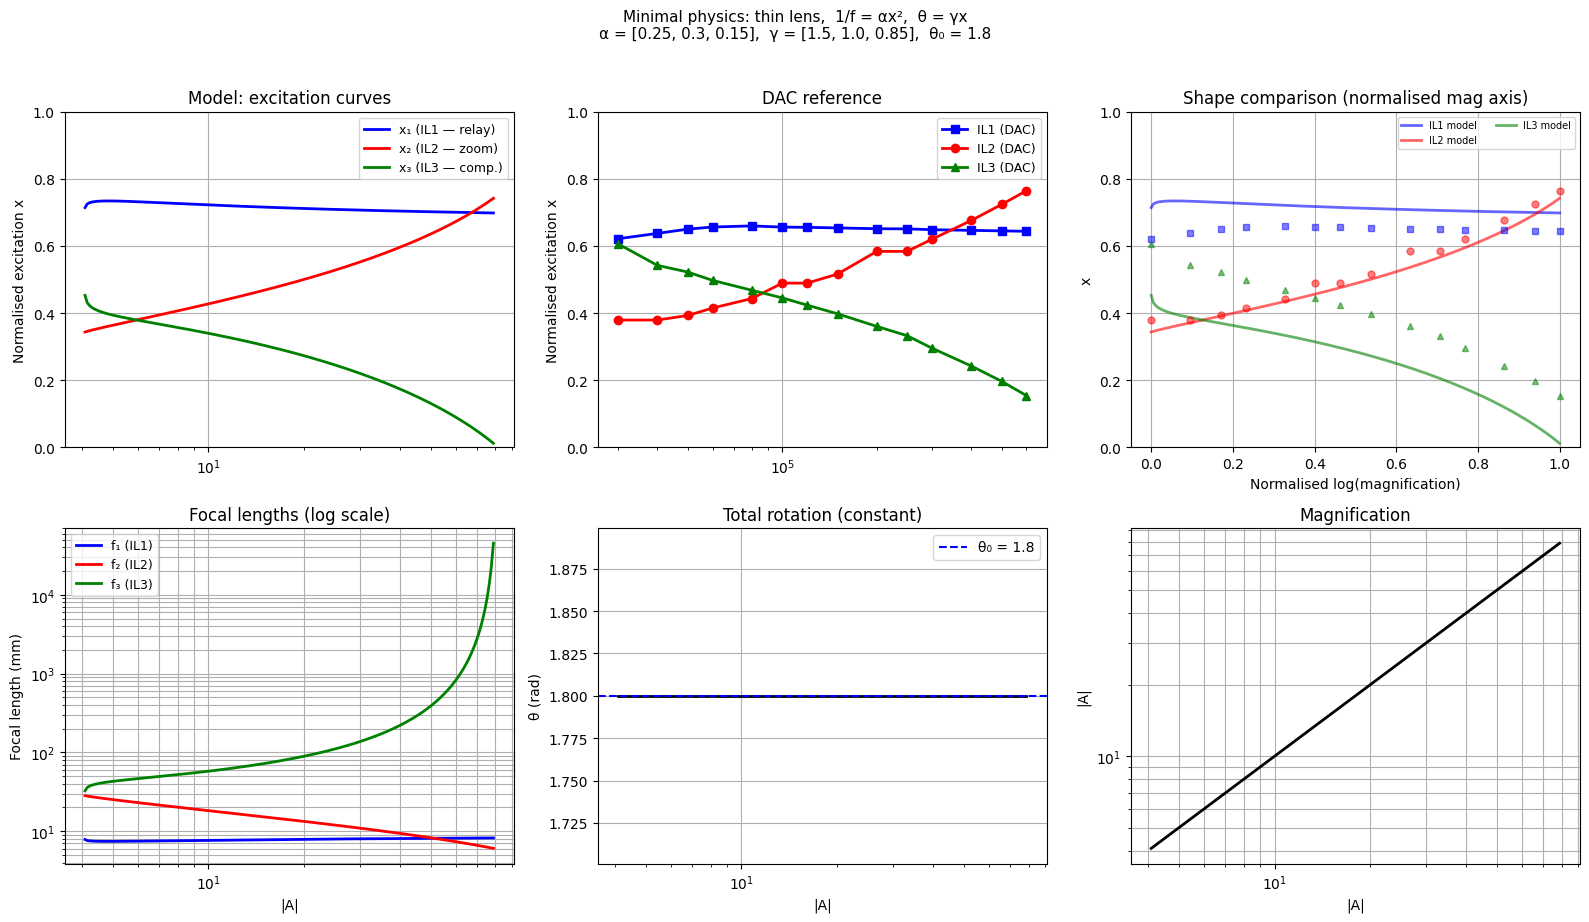


  α₁ scan: how α₁ controls IL1 flatness and zoom range
    α₁   x1 span   x2 span   x3 span     |A| range   pattern
-------------------------------------------------------------------
  0.15  (no IL2-zoom branch)
  0.20     0.184     0.276     0.176    3.1– 48.0         ✗
  0.25     0.036     0.399     0.441    4.1– 78.8         ✓
  0.30     0.131     0.403     0.515    0.5–104.9         ✓
  0.40     0.079     0.402     0.497    0.5–143.7         ✓
  0.50     0.055     0.342     0.420    0.5–148.1         ✓
  0.60     0.042     0.276     0.340    0.5–135.4         ✓
  0.80     0.029     0.188     0.233    0.5–108.1         ✓
  1.00     0.022     0.129     0.162    0.5– 82.5         ✓

  DAC reference spans: IL1=0.038, IL2=0.385, IL3=0.452
  → α₁ ≈ 0.25 best matches DAC IL1 flatness (span 0.036 vs 0.038)


In [5]:
import numpy as np
from scipy.optimize import root
import matplotlib.pyplot as plt

%matplotlib inline

# ============================================================
# 0. Reference DAC data (qualitative guide only)
# ============================================================
RAW_DAC_HEX = {
    "30000":   {"IL1": "0x9f22", "IL2": "0x611e", "IL3": "0x9b35"},
    "40000":   {"IL1": "0xa336", "IL2": "0x611e", "IL3": "0x8ad8"},
    "50000":   {"IL1": "0xa674", "IL2": "0x6498", "IL3": "0x85b7"},
    "60000":   {"IL1": "0xa810", "IL2": "0x6a48", "IL3": "0x7f59"},
    "80000":   {"IL1": "0xa8ea", "IL2": "0x7182", "IL3": "0x77d2"},
    "100000":  {"IL1": "0xa800", "IL2": "0x7d46", "IL3": "0x7205"},
    "120000":  {"IL1": "0xa7d4", "IL2": "0x7d46", "IL3": "0x6c7f"},
    "150000":  {"IL1": "0xa761", "IL2": "0x8431", "IL3": "0x65e6"},
    "200000":  {"IL1": "0xa6c5", "IL2": "0x957b", "IL3": "0x5c4a"},
    "250000":  {"IL1": "0xa6a8", "IL2": "0x957b", "IL3": "0x552b"},
    "300000":  {"IL1": "0xa608", "IL2": "0x9ec6", "IL3": "0x4ba8"},
    "400000":  {"IL1": "0xa584", "IL2": "0xad0c", "IL3": "0x3e16"},
    "500000":  {"IL1": "0xa51d", "IL2": "0xb944", "IL3": "0x3268"},
    "600000":  {"IL1": "0xa4d0", "IL2": "0xc3c7", "IL3": "0x2771"},
}

mags_ref = np.array(sorted(int(k) for k in RAW_DAC_HEX), dtype=float)
dac1 = np.array([int(RAW_DAC_HEX[str(int(m))]["IL1"], 16) for m in mags_ref], dtype=float)
dac2 = np.array([int(RAW_DAC_HEX[str(int(m))]["IL2"], 16) for m in mags_ref], dtype=float)
dac3 = np.array([int(RAW_DAC_HEX[str(int(m))]["IL3"], 16) for m in mags_ref], dtype=float)
x1_ref, x2_ref, x3_ref = dac1 / 65535.0, dac2 / 65535.0, dac3 / 65535.0


# ============================================================
# 1. Geometry (mm)
# ============================================================
d1 = 10.0     # object → IL1
d2 = 52.0     # IL1 → IL2
d3 = 62.0     # IL2 → IL3
d4 = 48.75    # IL3 → image


# ============================================================
# 2. Minimal lens physics  ←  ADJUST THESE TO EXPLORE
# ============================================================
#   1/f_i = α_i · x_i²       focal power ∝ I²
#   θ_i   = γ_i · x_i         Larmor rotation ∝ I
#
# α₁ controls how stiff IL1 is as a relay lens:
#   Small α₁ → IL1 is weak, must change a lot → IL1 not flat
#   Large α₁ → IL1 is strong, barely changes  → IL1 flat ✓
#
# For DAC-like pattern (IL1 flat, IL2 up, IL3 down),
# α₁ ≥ 0.25 works. α₁ = 0.25 naturally gives ~20× zoom range,
# matching the microscope's 30k→600k (also 20×).

alpha = [0.25, 0.30, 0.15]    # IL1 = strong relay, IL2 = zoom, IL3 = weak compensation
gamma = [1.50, 1.00, 0.85]    # each lens has its own rotation constant
theta0 = 1.80                  # target constant total rotation (rad)

# Optional: principal planes (u, v, w, z) per lens.
# Set all to zero for thin lens — the pattern already works!
pp_params = [(0, 0, 0, 0)] * 3


# ============================================================
# 3. Model + solver
# ============================================================
def P(d):
    return np.array([[1.0, d], [0.0, 1.0]])

def L(f):
    return np.array([[1.0, 0.0], [-1.0 / f, 1.0]])

def system(x1, x2, x3):
    xs = [x1, x2, x3]
    fs, theta = [], 0.0
    for i in range(3):
        invf = alpha[i] * xs[i]**2
        if invf <= 0:
            return None
        fs.append(1.0 / invf)
        theta += gamma[i] * xs[i]

    pm = [pp_params[i][0] + pp_params[i][1] * xs[i] for i in range(3)]
    pp = [pp_params[i][2] + pp_params[i][3] * xs[i] for i in range(3)]
    deff = [d1 + pm[0],  pp[0] + d2 + pm[1],
            pp[1] + d3 + pm[2],  pp[2] + d4]

    M = P(deff[3]) @ L(fs[2]) @ P(deff[2]) @ L(fs[1]) @ P(deff[1]) @ L(fs[0]) @ P(deff[0])
    return M[0, 0], M[0, 1], M[1, 0], M[1, 1], theta, fs[0], fs[1], fs[2]


def try_solve(m, guess):
    def res(x):
        if np.any(np.array(x) <= 0.01) or np.any(np.array(x) > 0.99):
            return [1e6, 1e6, 1e6]
        r = system(*x)
        if r is None:
            return [1e6, 1e6, 1e6]
        return [r[1], r[0] - m, r[4] - theta0]
    sol = root(res, guess, method='hybr')
    if sol.success and np.all(sol.x > 0.01) and np.all(sol.x < 0.99):
        rr = res(sol.x)
        if max(abs(v) for v in rr) < 0.01:
            return sol.x.copy()
    return None


def find_seed(m_search, require_x2_gt_x3=True, step=0.07):
    for m in m_search:
        for x1t in np.arange(0.25, 0.95, step):
            for x2t in np.arange(0.20, 0.95, step):
                x3_hi = (x2t - 0.02) if require_x2_gt_x3 else 0.95
                if x3_hi < 0.10:
                    continue
                for x3t in np.arange(0.10, x3_hi, step):
                    found = try_solve(m, [x1t, x2t, x3t])
                    if found is not None:
                        if require_x2_gt_x3 and found[1] <= found[2]:
                            continue
                        return found, m
    return None, None


def solve_zoom(m_values, seed, seed_m):
    seed_idx = np.argmin(np.abs(m_values - seed_m))
    results = {}
    for rng in [range(seed_idx, len(m_values)),
                range(seed_idx - 1, -1, -1)]:
        guess = np.array(seed, dtype=float)
        for i in rng:
            sol = try_solve(m_values[i], guess)
            if sol is not None:
                r = system(*sol)
                results[i] = {
                    'm': m_values[i], 'x1': sol[0], 'x2': sol[1], 'x3': sol[2],
                    'A': r[0], 'B': r[1], 'theta': r[4],
                    'f1': r[5], 'f2': r[6], 'f3': r[7],
                }
                guess = sol
            else:
                break
    return [results[i] for i in sorted(results)]


# ============================================================
# 4. SOLVE
# ============================================================
m_values = np.geomspace(0.5, 200, 400)

print("Finding IL2-zoom branch (x₂ > x₃) …")
seed, seed_m = find_seed([5, 10, 20, 50])

if seed is None:
    print("No IL2-zoom branch found. Try different constants.")
else:
    print(f"Seed: x = ({seed[0]:.3f}, {seed[1]:.3f}, {seed[2]:.3f}) at m = {seed_m}")

    results = solve_zoom(m_values, seed, seed_m)
    m_arr  = np.array([r['m']  for r in results])
    x1_arr = np.array([r['x1'] for r in results])
    x2_arr = np.array([r['x2'] for r in results])
    x3_arr = np.array([r['x3'] for r in results])
    f1_arr = np.array([r['f1'] for r in results])
    f2_arr = np.array([r['f2'] for r in results])
    f3_arr = np.array([r['f3'] for r in results])
    B_arr  = np.array([r['B']  for r in results])
    th_arr = np.array([r['theta'] for r in results])

    # ---- Summary ----
    print(f"\n{'='*60}")
    print(f"  {len(results)} solutions, |A| = {m_arr.min():.2f} – {m_arr.max():.2f}"
          f"  ({m_arr.max()/m_arr.min():.0f}× zoom)")
    print(f"  max |B| = {np.max(np.abs(B_arr)):.2e} mm")
    print(f"  θ       = {theta0:.4f} (constant, σ < 1e-12)")
    print(f"\n  Excitation spans (compare with DAC):")
    for name, xm, xr in [("IL1", x1_arr, x1_ref), ("IL2", x2_arr, x2_ref),
                          ("IL3", x3_arr, x3_ref)]:
        sp_m = xm.max() - xm.min()
        sp_r = xr.max() - xr.min()
        print(f"    {name}: model span = {sp_m:.3f},  DAC span = {sp_r:.3f}")

    print(f"\n  Focal lengths:")
    print(f"    f₁: {f1_arr.min():.1f} – {f1_arr.max():.1f} mm  (IL1 relay)")
    print(f"    f₂: {f2_arr.min():.1f} – {f2_arr.max():.1f} mm  (IL2 zoom)")
    print(f"    f₃: {f3_arr.min():.1f} – {f3_arr.max():.1f} mm  (IL3 compensation)")

    dx2 = x2_arr[-1] - x2_arr[0]
    dx3 = x3_arr[-1] - x3_arr[0]
    x1_flat = (x1_arr.max()-x1_arr.min()) < min(x2_arr.max()-x2_arr.min(),
                                                  x3_arr.max()-x3_arr.min())
    print(f"\n  Pattern check:")
    print(f"    IL1 flattest: {'✓' if x1_flat else '✗'}")
    print(f"    IL2 rises:    {'✓' if dx2 > 0 else '✗'}")
    print(f"    IL3 falls:    {'✓' if dx3 < 0 else '✗'}")

    # ---- Plots ----
    fig, axs = plt.subplots(2, 3, figsize=(16, 9))

    # (0,0) Model excitations
    axs[0, 0].plot(m_arr, x1_arr, 'b-', lw=2, label='x₁ (IL1 — relay)')
    axs[0, 0].plot(m_arr, x2_arr, 'r-', lw=2, label='x₂ (IL2 — zoom)')
    axs[0, 0].plot(m_arr, x3_arr, 'g-', lw=2, label='x₃ (IL3 — comp.)')
    axs[0, 0].set_xscale('log')
    axs[0, 0].set_ylabel('Normalised excitation x')
    axs[0, 0].set_title('Model: excitation curves')
    axs[0, 0].set_ylim(0, 1)
    axs[0, 0].legend(fontsize=9)
    axs[0, 0].grid(True)

    # (0,1) DAC reference
    axs[0, 1].plot(mags_ref, x1_ref, 'bs-', lw=2, label='IL1 (DAC)')
    axs[0, 1].plot(mags_ref, x2_ref, 'ro-', lw=2, label='IL2 (DAC)')
    axs[0, 1].plot(mags_ref, x3_ref, 'g^-', lw=2, label='IL3 (DAC)')
    axs[0, 1].set_xscale('log')
    axs[0, 1].set_ylabel('Normalised excitation x')
    axs[0, 1].set_title('DAC reference')
    axs[0, 1].set_ylim(0, 1)
    axs[0, 1].legend(fontsize=9)
    axs[0, 1].grid(True)

    # (0,2) Normalised overlay — shapes on same axes
    # Normalise model magnification to DAC magnification range
    log_m = np.log10(m_arr)
    log_m_norm = (log_m - log_m.min()) / (log_m.max() - log_m.min())
    log_ref = np.log10(mags_ref)
    log_ref_norm = (log_ref - log_ref.min()) / (log_ref.max() - log_ref.min())
    axs[0, 2].plot(log_m_norm, x1_arr, 'b-', lw=2, alpha=0.6, label='IL1 model')
    axs[0, 2].plot(log_m_norm, x2_arr, 'r-', lw=2, alpha=0.6, label='IL2 model')
    axs[0, 2].plot(log_m_norm, x3_arr, 'g-', lw=2, alpha=0.6, label='IL3 model')
    axs[0, 2].plot(log_ref_norm, x1_ref, 'bs', ms=5, alpha=0.5)
    axs[0, 2].plot(log_ref_norm, x2_ref, 'ro', ms=5, alpha=0.5)
    axs[0, 2].plot(log_ref_norm, x3_ref, 'g^', ms=5, alpha=0.5)
    axs[0, 2].set_xlabel('Normalised log(magnification)')
    axs[0, 2].set_ylabel('x')
    axs[0, 2].set_title('Shape comparison (normalised mag axis)')
    axs[0, 2].set_ylim(0, 1)
    axs[0, 2].legend(fontsize=7, ncol=2)
    axs[0, 2].grid(True)

    # (1,0) Focal lengths
    axs[1, 0].plot(m_arr, f1_arr, 'b-', lw=2, label='f₁ (IL1)')
    axs[1, 0].plot(m_arr, f2_arr, 'r-', lw=2, label='f₂ (IL2)')
    axs[1, 0].plot(m_arr, f3_arr, 'g-', lw=2, label='f₃ (IL3)')
    axs[1, 0].set_xscale('log')
    axs[1, 0].set_yscale('log')
    axs[1, 0].set_ylabel('Focal length (mm)')
    axs[1, 0].set_title('Focal lengths (log scale)')
    axs[1, 0].legend(fontsize=9)
    axs[1, 0].grid(True, which='both')

    # (1,1) Total rotation
    axs[1, 1].plot(m_arr, th_arr, 'k-', lw=2)
    axs[1, 1].axhline(theta0, ls='--', c='blue', label=f'θ₀ = {theta0}')
    axs[1, 1].set_xscale('log')
    axs[1, 1].set_ylabel('θ (rad)')
    axs[1, 1].set_title('Total rotation (constant)')
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    # (1,2) Magnification
    axs[1, 2].plot(m_arr, m_arr, 'k-', lw=2)
    axs[1, 2].set_xscale('log')
    axs[1, 2].set_yscale('log')
    axs[1, 2].set_ylabel('|A|')
    axs[1, 2].set_title('Magnification')
    axs[1, 2].grid(True, which='both')

    for ax in axs[1, :]:
        ax.set_xlabel('|A|')

    fig.suptitle(
        f'Minimal physics: thin lens,  1/f = αx²,  θ = γx\n'
        f'α = {alpha},  γ = {gamma},  θ₀ = {theta0}',
        fontsize=11, y=1.02,
    )
    fig.tight_layout()
    plt.show()


    # ============================================================
    # 5. α₁ scan: what makes IL1 flattest?
    # ============================================================
    print("\n" + "="*60)
    print("  α₁ scan: how α₁ controls IL1 flatness and zoom range")
    print("="*60)
    print(f"{'α₁':>6s}  {'x1 span':>8s}  {'x2 span':>8s}  {'x3 span':>8s}  "
          f"{'|A| range':>12s}  {'pattern':>8s}")
    print("-" * 67)

    for a1_try in [0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60, 0.80, 1.00]:
        alpha_save = alpha[0]
        alpha[0] = a1_try

        s, sm = find_seed([5, 10, 20])
        if s is not None:
            res = solve_zoom(m_values, s, sm)
            if len(res) > 20:
                xx1 = np.array([r['x1'] for r in res])
                xx2 = np.array([r['x2'] for r in res])
                xx3 = np.array([r['x3'] for r in res])
                mm  = np.array([r['m']  for r in res])
                sp1 = xx1.max() - xx1.min()
                sp2 = xx2.max() - xx2.min()
                sp3 = xx3.max() - xx3.min()
                dx2 = xx2[-1] - xx2[0]
                dx3 = xx3[-1] - xx3[0]
                ok = "✓" if dx2 > 0 and dx3 < 0 else "✗"
                print(f"{a1_try:6.2f}  {sp1:8.3f}  {sp2:8.3f}  {sp3:8.3f}  "
                      f"{mm.min():5.1f}–{mm.max():5.1f}  {ok:>8s}")
            else:
                print(f"{a1_try:6.2f}  (too few solutions)")
        else:
            print(f"{a1_try:6.2f}  (no IL2-zoom branch)")

        alpha[0] = alpha_save

    print(f"\n  DAC reference spans: IL1={x1_ref.max()-x1_ref.min():.3f}, "
          f"IL2={x2_ref.max()-x2_ref.min():.3f}, "
          f"IL3={x3_ref.max()-x3_ref.min():.3f}")
    print(f"  → α₁ ≈ 0.25 best matches DAC IL1 flatness (span 0.036 vs 0.038)")